# METEOSAT IMAGES THROUGH WMS +PYTHON

In [32]:
from owslib.wms import WebMapService
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

In [33]:
#  connect to EUMETSAT WebMapService
WMS = WebMapService("HTTPS://VIEW.EUMETSAT.INT/GEOSERVER/WMS", version="1.3.0")

In [34]:
for layer in WMS.contents:
    print(layer)

osmgray:dark
osmgray:dark_labels
osmgray:light
osmgray:light_labels
osmgray:builtup_area
msg_fes:clm
msg_iodc:clm
msg_fes:cth
msg_iodc:cth
copernicus:daily_sentinel3ab_olci_l1_rgb_fulres
copernicus:daily_sentinel3ab_olci_l2_chl_fullres
copernicus:daily_sentinel3ab_slstr_l2p_sst_fullres
msg_fes:fire
msg_iodc:fire
msg_fes:gii_kindex
msg_iodc:gii_kindex
msg_fes:gii_liftedindex
msg_iodc:gii_liftedindex
backgrounds:graticules-dark
backgrounds:graticules-light
msg_fes:h60b
msg_iodc:h63
msg_fes:ir039
msg_iodc:ir039
msg_rss:ir039_nrt
mtg_fd:ir105_hrfi
msg_fes:ir108
msg_iodc:ir108
osmgray:land_polygons
mtg_fd:li_afa
eps:m01_ascat_wind
eps:m01_ir108
eps:m01_orbital_tracks
eps:m01_rgb_124
eps:m01_rgb_natural_fog
eps:m02_ascat_wind
eps:m02_ir108
eps:m02_orbital_tracks
eps:m02_rgb_124
eps:m02_rgb_natural_fog
eps:m03_ascat_wind
eps:m03_ir108
eps:m03_orbital_tracks
eps:m03_rgb_124
eps:m03_rgb_natural_fog
osmgray:ne_10m_admin_0_boundary_lines_land
osmgray:ne_10m_admin_0_countries_points
osmgray:ne_10m

In [35]:
#fetch image for kenya 
def get_meteosat_ir_KENYA(bbox=(33, -5, 43, 5), size=(800, 800)):
    img = WMS.getmap(
        # layers=["msg_fes:ir108"],
        layers=["msg_fes:ir108", "msg_fes:rgb_convection"],
        srs="EPSG:4326",
        bbox=bbox,
        size=size,
        format="image/png",
        time="2026-05-11T16:30:00Z",
        # transparent=True,l
    )
    return Image.open(BytesIO(img.read()))

# "msg_fes:ir108", "msg_fes:rgb_natural"

In [36]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


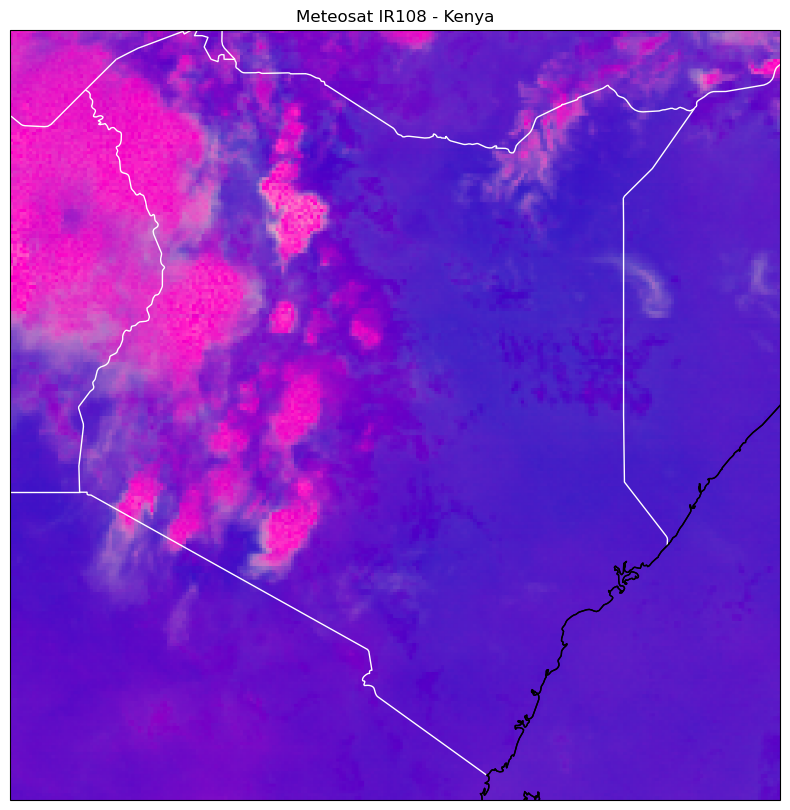

In [37]:
image = get_meteosat_ir_KENYA()

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.imshow(image, origin="upper", extent=(33, 43, -5, 5), transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, color="white")


ax.set_title("Meteosat IR108 - Kenya")
ax.coastlines()
plt.show()